In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py
import astropy.units as u
import astropy.coordinates as coord


from gen_streams import gen_stream_data
from gen_foreground import gen_foreground_data
from gen_background import gen_background_data


This cell prints out any streams from TNG halo 523889 beyond 20 kpc with negative declinations (meaning they'd be in the LSST footprint). 

In [4]:
haloid = "523889"
streamcat_path = "/nfs/turbo/lsa-ognedin/cphh/stream_catalogs/final-catalogs"

clusters = h5py.File(f"{streamcat_path}/{haloid}/{haloid}_clusters.hdf5", "r")

for key in clusters.keys():
    cluster = clusters[key]

    c_galcen = coord.SkyCoord(x=cluster['x'][-1]*u.kpc, y=cluster['y'][-1]*u.kpc, z=cluster['z'][-1]*u.kpc, frame='galactocentric')
    r_galcen = np.sqrt(cluster['x'][-1]**2 + cluster['y'][-1]**2 + cluster['z'][-1]**2)*u.kpc
    c_icrs = c_galcen.transform_to(coord.ICRS)
    c_gal = c_galcen.transform_to(coord.Galactic)

    if c_icrs.dec.degree < 0 and r_galcen > 20*u.kpc and c_gal.b.degree > 20:
        print(key, f"{c_icrs.dec.degree:.3f}", f"{r_galcen:.3f}, {c_gal.b.degree:.3f}")


222 -31.417 31.102 kpc, 29.015
227 -18.472 31.871 kpc, 38.847
231 -4.045 43.056 kpc, 44.537
234 -17.779 42.441 kpc, 40.462
239 -7.152 44.861 kpc, 36.190
251 -7.110 31.544 kpc, 53.809
262 -21.080 63.237 kpc, 23.258
271 -7.495 50.015 kpc, 34.075
275 -12.416 289.248 kpc, 47.656
284 -8.167 248.285 kpc, 46.862


In [5]:

def generate_catalog_for_stream(haloid, stream_id, streamcat_path, output_dir=None, search_radius=8):
    """    
    For a given stream, generate the full catalog with LSST foreground, background galaxies, and extinction. The catalog is saved as a .hdf5 file

    Parameters:

    haloid (str): The haloid of the stream in the stream catalog
    stream_id (str): The stream id in the stream catalog.
    streamcat_path (str): The path to the stream catalog hdf5 files
    output_dir (str, optional): The directory to save the output .hdf5 file. If None, the file will not be saved. Defaults to None.
    search_radius (float, optional): The radius (in degrees) around the stream to search for foreground and background objects. Defaults to 8 degrees.


    """


    print("Generating stream data...")
    cluster_icrs, stream_icrs, mags = gen_stream_data(haloid, stream_id, streamcat_path)
    


    print("Generating foreground data...")
    df_foreground = gen_foreground_data(cluster_icrs.ra.degree, cluster_icrs.dec.degree , search_radius)
    

    print("Generating background data...")
    data_bkg = gen_background_data(cluster_icrs, search_radius)
    


    print("Writing to File...")

    stream_df = pd.DataFrame({
    'ra': stream_icrs.ra.degree,
    'dec': stream_icrs.dec.degree,
    'g_mag': mags[0],
    'r_mag': mags[1],
    'pm_ra_cosdec': stream_icrs.pm_ra_cosdec.to_value(u.mas / u.yr),
    'pm_dec': stream_icrs.pm_dec.to_value(u.mas / u.yr),
    'type': np.full(len(stream_icrs), 1),
    })

    foreground_df = pd.DataFrame({
    'ra': np.asarray(df_foreground['ra']),
    'dec': np.asarray(df_foreground['dec']),
    'g_mag': np.asarray(df_foreground['gmag']),
    'r_mag': np.asarray(df_foreground['rmag']),
    'pm_ra_cosdec': np.asarray(df_foreground['pmracosd']),
    'pm_dec': np.asarray(df_foreground['pmdec']),
    'type': np.full(len(df_foreground), 2),
    })

    background_df = pd.DataFrame({
    'ra': np.asarray(data_bkg['ra']),
    'dec': np.asarray(data_bkg['dec']),
    'g_mag': np.asarray(data_bkg['mag_g_cModel']),
    'r_mag': np.asarray(data_bkg['mag_r_cModel']),
    'pm_ra_cosdec': np.full(len(data_bkg['ra']), np.nan),
    'pm_dec': np.full(len(data_bkg['ra']), np.nan),
    'type': np.full(len(data_bkg['ra']), 3),
    })

    df_all = pd.concat([stream_df, foreground_df, background_df], ignore_index=True)
    df_all = df_all[['ra', 'dec', 'g_mag', 'r_mag', 'pm_ra_cosdec', 'pm_dec', 'type']]

   

    if output_dir is not None:
        df_all.to_hdf(f"{output_dir}/{haloid}_stream_{stream_id}.hdf5", key='df', mode='w')


    print("Finished.")




In [6]:
streamcat_path = "/nfs/turbo/lsa-ognedin/cphh/stream_catalogs/final-catalogs"

generate_catalog_for_stream("523889", "262", streamcat_path, output_dir="/nfs/turbo/lsa-ognedin/cphh/lsst_gc_streams/mocks")


Generating stream data...
Generating foreground data...
Generating background data...
Writing to File...
Finished.


In [7]:
import pandas as pd

cat_path = "/nfs/turbo/lsa-ognedin/cphh/lsst_gc_streams/mocks/"

df = pd.read_hdf(f"{cat_path}/523889_stream_262.hdf5", key='df')

In [8]:
df

,ra,dec,g_mag,r_mag,pm_ra_cosdec,pm_dec,type
0,144.329384,-21.791163,26.885830,26.223817,0.091582,-0.092861,1
1,146.063635,-20.262810,32.070687,30.672983,0.103730,-0.107341,1
2,144.572962,-21.632412,30.460802,29.296768,0.098019,-0.095239,1
3,145.811657,-20.293451,29.692035,28.575792,0.099623,-0.106226,1
4,144.095445,-21.909705,31.192312,29.956065,0.092220,-0.092742,1
...,...,...,...,...,...,...,...
64240709,140.646075,-14.334478,26.961985,26.310623,NaN,NaN,3
64240710,140.648007,-14.329778,26.461171,26.395490,NaN,NaN,3
64240711,140.556059,-14.388409,27.043820,26.351678,NaN,NaN,3
64240712,140.555740,-14.388866,26.644648,26.219141,NaN,NaN,3


In [10]:
(df[df['type'] == 1]['g_mag'] < 24).sum()

np.int64(166)

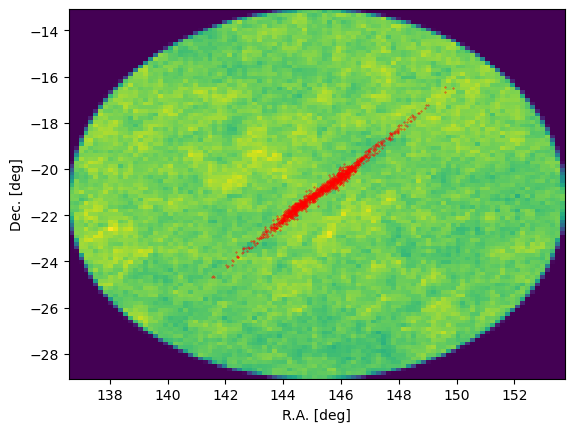

In [ ]:
df_stream = df[df['type'] == 1]
df_foreground = df[df['type'] == 2]
df_bkg = df[df['type'] == 3]


plt.hist2d(df_foreground['ra'], df_foreground['dec'], bins=100)
plt.hist2d(df_bkg['ra'], df_bkg['dec'], bins=100)
plt.scatter(df_stream['ra'][df_stream['g_mag'] < 27.5], df_stream['dec'][df_stream['g_mag'] < 27.5], 
            color='red', label='Stream Stars', s=0.1)

plt.xlabel('R.A. [deg]')
plt.ylabel('Dec. [deg]')

plt.show()